In [2]:
# Imports
from math import pi, cos, sin, sqrt
import numpy as np
from matplotlib import pyplot as plt 

#-------------------------------------------------------------------------------
#                               get_pentagon
#-------------------------------------------------------------------------------
def get_pentagon(centerPoint=(0,0), rotation=0, sideLength=1.0):
    ''' returns the points of the verticies of a pentagon '''
    # https://mathworld.wolfram.com/RegularPentagon.html
    # https://mathworld.wolfram.com/RegularPolygon.html

    a = sideLength * (0.1*sqrt(50 + 10*sqrt(5)))

    c1 = a * cos(2*pi/5)
    c2 = a * cos(pi/5)
    s1 = a * sin(2*pi/5)
    s2 = a * sin(4*pi/5)

    pt1 = (0, a)
    pt2 = (s1, c1)
    pt3 = (s2, -c2)
    pt4 = (-s2, -c2)
    pt5 = (-s1, c1)

    points = np.matrix((pt1, pt2, pt3, pt4, pt5))

    # Apply the rotation
    points = rotate_2D(points, rotation)

    # Add the offset
    points = translate_2D(points, x=centerPoint[0], y=centerPoint[1])

    return points


#-------------------------------------------------------------------------------
#                                  rotate_2D
#-------------------------------------------------------------------------------
def rotate_2D(points=None, rotation=0):
    ''' rotate points in 2D.  rotation specified in degrees. '''
    # https://en.wikipedia.org/wiki/Rotation_matrix

    R = np.matrix([[cos(rotation*pi/180.), -sin(rotation*pi/180.)], [sin(rotation*pi/180.), cos(rotation*pi/180.)]])
    points = np.matrix(points)              
    newPoints = R * points.T

    return newPoints.T


#-------------------------------------------------------------------------------
#                               translate_2D
#-------------------------------------------------------------------------------
def translate_2D(points=(), x=0, y=0):
    points[:,0] += x
    points[:,1] += y
    return points


#-------------------------------------------------------------------------------
#                              get_distance
#-------------------------------------------------------------------------------
def get_distance_2D(pt1, pt2):
    ''' Get the distance between two points. '''

    if (type(pt1) == type(())) or (type(pt1) == type([])):
        pt1 = np.matrix(pt1)

    if (type(pt2) == type(())) or (type(pt2) == type([])):
        pt2 = np.matrix(pt2)

    x1 = float(pt1[0, 0])
    y1 = float(pt1[0, 1])

    x2 = float(pt2[0, 0])
    y2 = float(pt2[0, 1])

    distance = sqrt((x2-x1)**2 + (y2-y1)**2)

    return distance


#-------------------------------------------------------------------------------
#                              capture_picture
#-------------------------------------------------------------------------------
def capture_picture(points):
    ''' Simulates capturing an image.  It only returns points along one axis (no depth information) '''
    cameraPoints = points[:,1]
    return cameraPoints


#-------------------------------------------------------------------------------
#                              get_coord_list
#-------------------------------------------------------------------------------
def get_coord_list(matrix):
    ''' Returns a plot-friendly coordinate list from a numpy matrix. '''

    x = matrix[:,0].flatten().tolist()[0]
    y = matrix[:,1].flatten().tolist()[0]
    x.append(x[0])
    y.append(y[0])

    return (x, y)


![Equations](Rotation_Equations.jpg)

In [3]:
#-------------------------------------------------------------------------------
#                             reconstruct_depth
#-------------------------------------------------------------------------------
def reconstruct_depth(initialPoints, finalPoints, rotationAmount, error=False):
    '''
    * initialPoints -  A numpy matrix with the initial values. This is a vector
                       of y-coordinates only (the x-coordinates were stripped 
                       by the "capture_picture" function)
    * finalPoints -    This is similar to the initialPoints, but after the shape
                       has been rotated by some amount.
    * rotationAmount - this is the amount that the points were rotated, in
                       degrees.
    '''

    xInitial = (finalPoints - initialPoints * np.cos(rotationAmount * pi/180.0)) / np.sin(rotationAmount * pi/180.0)
    xFinal = xInitial * np.cos(rotationAmount * pi/180.0) - initialPoints * np.sin(rotationAmount * pi/180.0)

    if error == True:
        # Create a random vector (-1 to 1) to add to the X values
        e = 2 * np.matrix(np.random.rand(np.size(xFinal), 1) - 0.5)

        # Scale the error to be a percentage (± 1%).
        e /= 100
        e *= 5    # convert to a ± 5% error
        e += 1

        # Add the error to the xValues
        xFinal = np.multiply(xFinal, e)

    # Create a set of coordinates fully reconstructed
    coords = np.hstack((xFinal, finalPoints))

    return coords

In [4]:
print( 2 * np.matrix(np.random.rand(10,1) - 0.5))

[[-0.8979469 ]
 [-0.97604016]
 [-0.03125676]
 [-0.62344143]
 [-0.22910467]
 [-0.46573021]
 [ 0.28727705]
 [ 0.24541171]
 [-0.59933313]
 [-0.6932132 ]]


1.2088971014631473
1.2088971014631473
1.2088971014631473
0.49999999999999994
-0.5
0.8462910576170319
-0.846291057617032


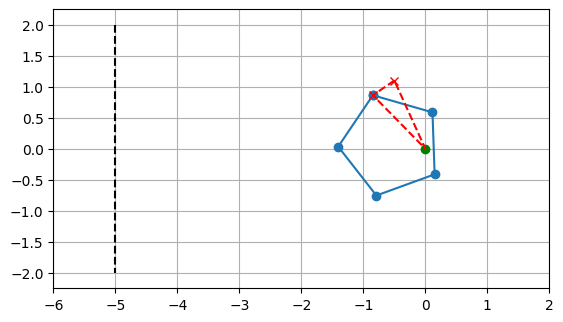

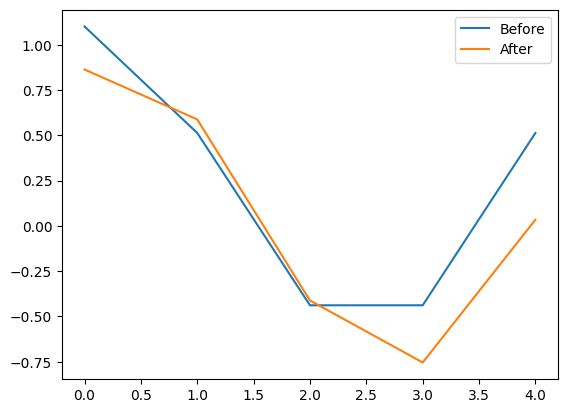

In [5]:
# Define the camera position
xCamera = -5

# Get the coordinates of a pentagon
xCenter = -0.5
yCenter = 0.25
coords = get_pentagon(centerPoint=(xCenter, yCenter), rotation=0, sideLength=1.0)


pt1 = coords[0,:].flatten().tolist()[0]
yBefore = coords[:,1]

# Rotate the pentagon about the (0,0) point
rotation = 20.0
coords = rotate_2D(coords, rotation=rotation)

pt2 = coords[0,:].flatten().tolist()[0]
yAfter = coords[:,1]



x1 = pt1[1]
x2 = pt2[1]

d1 = get_distance_2D(pt1, (0,0))
d2 = get_distance_2D(pt2, (0,0))

theta = rotation * pi / 180.0
L = sqrt(x1**2 + ((x1*cos(theta) - x2) / sin(theta))**2)
print(L)

print(d1)
print(d2)

y1 = (x1 * cos(theta) - x2) / sin(theta)

print(y1)
print(pt1[0])

y2 = x1 * sin(theta) + y1 * cos(theta)
print(y2)
print(pt2[0])



# Get the x/y values into their own lists
x = coords[:,0].flatten().tolist()[0]
y = coords[:,1].flatten().tolist()[0]
x.append(x[0])
y.append(y[0])

# Create a plot with the results
fig = plt.figure()
plt.plot(x, y, '-o')
plt.plot(0, 0, 'go')

#plt.plot([x[0], x[0], 0, x[0]], [y[0], 0, 0, y[0]], 'r--')
plt.plot([pt1[0], pt2[0], 0, pt1[0]], [pt1[1], pt2[1], 0, pt1[1]], 'r--')

plt.plot(pt1[0], pt1[1], 'rx')
plt.plot(pt2[0], pt2[1], 'rx')

# Show the "camera"
plt.plot([xCamera, xCamera], [2, -2], 'k--')

plt.grid(True)
plt.axis('image')
plt.xlim([-6, 2])
plt.ylim([-2.25, 2.25])


# Create a plot with just the y-coordinates
fig2 = plt.figure()
plt.plot(yBefore)
plt.plot(yAfter)
plt.legend(['Before', 'After'])

plt.show()

# Simulate Rotation & Reconstruct

In [33]:
randVal = (np.random.rand() - 0.5) * 5
print(randVal)

0.8289204188117483


(-5.2780245929716285,
 0.8385164524041955,
 -2.2318090673136664,
 2.8679904135869956)

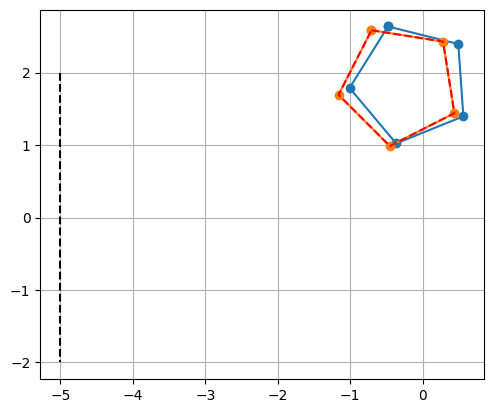

In [58]:
# Define the "camera" position (just for visualization)
xCamera = -5

# Get the initial pentagon
xCenter = (np.random.rand() - 0.5) * 5
yCenter = (np.random.rand() - 0.5) * 5
sideLen = 1.0
initialRotation = 22.0
coords = get_pentagon(centerPoint=(xCenter, yCenter), rotation=initialRotation, sideLength=sideLen)

# Get the x/y values into their own lists
xInitial,yInitial = get_coord_list(coords)

# Take a "picture"
picInitial = capture_picture(coords)

# Rotate the "crystal"
rotation = 5.0  # degrees
coords = rotate_2D(coords, rotation=rotation)

# Get the x/y values into their own lists
xFinal,yFinal = get_coord_list(coords)

# Take a "picture"
picFinal = capture_picture(coords)

# Reconstruct the depth information
reconstructedCoords = reconstruct_depth(picInitial, picFinal, rotation)

# Get the final x/y values into a list
xReconstructed, yReconstructed = get_coord_list(reconstructedCoords)


# Create a plot with the results
fig = plt.figure()
plt.plot(xInitial, yInitial, '-o')
plt.plot(xFinal, yFinal, '-o')

plt.plot(xReconstructed, yReconstructed, 'r--')

# Show the "camera"
plt.plot([xCamera, xCamera], [2, -2], 'k--')

plt.grid(True)
plt.axis('image')
#plt.xlim([-6, 2])
#plt.ylim([-2.25, 2.25])



# Simulate & Reconstruct With Measurement Error

(-2.25, 2.25)

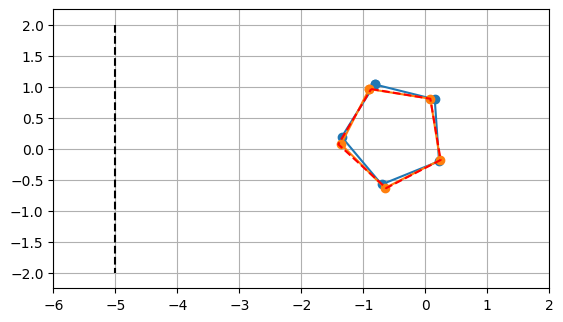

In [8]:
# Define the "camera" position (just for visualization)
xCamera = -5

# Get the initial pentagon
xCenter = -0.5
yCenter = 0.25
sideLen = 1.0
initialRotation = 22.0
coords = get_pentagon(centerPoint=(xCenter, yCenter), rotation=initialRotation, sideLength=sideLen)

# Get the x/y values into their own lists
xInitial,yInitial = get_coord_list(coords)

# Take a "picture"
picInitial = capture_picture(coords)

# Rotate the "crystal"
rotation = 5.0  # degrees
coords = rotate_2D(coords, rotation=rotation)

# Get the x/y values into their own lists
xFinal,yFinal = get_coord_list(coords)

# Take a "picture"
picFinal = capture_picture(coords)

# Reconstruct the depth information
reconstructedCoords = reconstruct_depth(picInitial, picFinal, rotation, error=True)

# Get the final x/y values into a list
xReconstructed, yReconstructed = get_coord_list(reconstructedCoords)


# Create a plot with the results
fig = plt.figure()
plt.plot(xInitial, yInitial, '-o')
plt.plot(xFinal, yFinal, '-o')

plt.plot(xReconstructed, yReconstructed, 'r--')

# Show the "camera"
plt.plot([xCamera, xCamera], [2, -2], 'k--')

plt.grid(True)
plt.axis('image')
plt.xlim([-6, 2])
plt.ylim([-2.25, 2.25])